# Set data directory

In [1]:
path = './data/'

# Preamble

Install the necessary packages:

In [2]:
"""
%pip install tol-colors
%pip install git@github.com:imagdau/aseMolec.git
%pip install ase
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install pyyaml
%pip install scipy
%pip install requests
%pip install pathlib
%pip install joblib
"""

'\n%pip install tol-colors\n%pip install git@github.com:imagdau/aseMolec.git\n%pip install ase\n%pip install pandas\n%pip install numpy\n%pip install matplotlib\n%pip install pyyaml\n%pip install scipy\n%pip install requests\n%pip install pathlib\n%pip install joblib\n'

In [3]:
import funcs as funcs
from ase.io import read, iread
import ase.units
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from aseMolec import pltProps as pp
from aseMolec import anaAtoms as aa
import pandas as pd
import numpy as np
import tol_colors as tc
cset = tc.tol_cset('bright')
plt.rc('axes', prop_cycle=plt.cycler('color', list(cset)))

tags = [
    'Periodic/PBED3/SEED1/DSET1',
    'Periodic/PBED2/SEED1/DSET1',
    'Periodic/B97D3/SEED1/DSET1',
]

scale = 1.5
fsize = 8*scale
plt.rcParams.update({'font.size': fsize})

/tmp/ipykernel_858644/1657182852.py:12: DeprecationWarning: tol_cset is soft-deprecated since 2.0, please use tol_colors.colorsets instead
  cset = tc.tol_cset('bright')


In [4]:
label_map = {
    'PBED3':'PBE-D3',
    'PBED2':'PBE-D2',
    'B97D3':'B97-D3',
}

traj_map = {
    'npt_000conEC_298K':'EMC',
    'npt_033conEC_298K':'EC:EMC (3:7)',
    'npt_066conEC_298K':'EC:EMC (7:3)',
    'npt_100conEC_313K':'EC',
}

___
# Download
## MLIP data

In [5]:
funcs.download_unpack(path, "periodic_metadata.yaml", "MLIP downloads")

./data/MLIP_MACE_Periodic_B97D3.zip
Unzipping ./data/MLIP_MACE_Periodic_B97D3.zip -> ./data/Periodic/B97D3


./data/MLIP_MACE_Periodic_PBED2.zip
Unzipping ./data/MLIP_MACE_Periodic_PBED2.zip -> ./data/Periodic/PBED2


./data/MLIP_MACE_Periodic_PBED3.zip
Unzipping ./data/MLIP_MACE_Periodic_PBED3.zip -> ./data/Periodic/PBED3


## MD simulation data

In [6]:
funcs.download_unpack(path, "periodic_metadata.yaml", "MDSims downloads")

./data/MDSims_1000atoms_1ns_Periodic_B97D3.zip
Unzipping ./data/MDSims_1000atoms_1ns_Periodic_B97D3.zip -> ./data/Periodic/B97D3


./data/MDSims_1000atoms_1ns_Periodic_PBED3.zip
Unzipping ./data/MDSims_1000atoms_1ns_Periodic_PBED3.zip -> ./data/Periodic/PBED3


./data/MDSims_1000atoms_1ns_Periodic_PBED2.zip
Unzipping ./data/MDSims_1000atoms_1ns_Periodic_PBED2.zip -> ./data/Periodic/PBED2


## Data overview

In [7]:
meta_df = funcs.yaml_to_multidf("periodic_metadata.yaml", ["Data set", "Labels"])
meta_df

Subset  Seeds  Number of structures  Number of atoms
Data set Labels                                                      
Periodic PBE-D2       1      1                   935            66188
         PBE-D3       1      1                   935            66188
         B97-D3       1      1                   935            66188

___
# Results

## Training errors

In [8]:
# Obtain data and store to dicts
xyz = dict()
for tag in tags:
    xyz[tag] = funcs.get_xyz(f'{path}{tag}/training/evaluation/*')

./data/Periodic/PBED3/SEED1/DSET1/training/evaluation/IBM23_PBED3.xyz


./data/Periodic/PBED2/SEED1/DSET1/training/evaluation/IBM23_PBED2.xyz


./data/Periodic/B97D3/SEED1/DSET1/training/evaluation/IBM23_B97D3BJ_Vasp.xyz


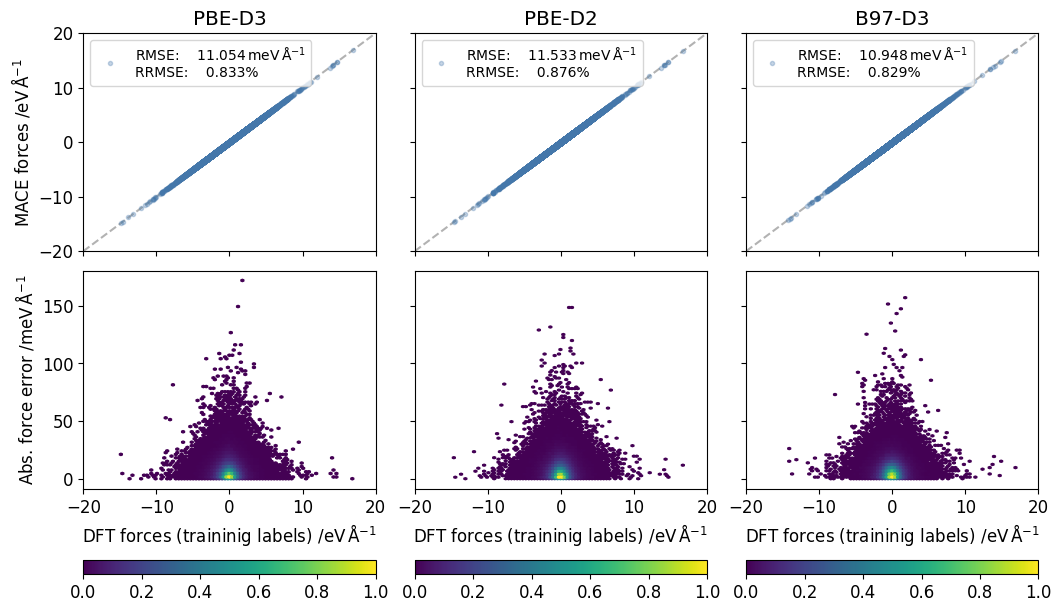

In [9]:
fig, axs = plt.subplots(2,len(tags), figsize=(7*scale, 4*scale), sharex=True, sharey='row', layout='constrained')
for i, k in enumerate(xyz):
    tag = tags[i]
    atoms = xyz[k][3:]      # First three structures are just reference atoms with 0 energy and force.
    data_set, labels, seed, dset_sample = tag.split('/')
    
    # Obtain forces and errors
    ## reference
    ref_forces = [a.calc.results['forces'] for a in atoms]
    ref_forces = np.concatenate(ref_forces).flatten()

    ## mace
    mace_forces = [a.arrays['MACE_forces'] for a in atoms]
    mace_forces = np.concatenate(mace_forces).flatten()
    rmse, rrmse = funcs.RMSE(ref_forces, mace_forces)

    # Plot correlations
    axs[0,i].set_title(label_map[labels])
    axs[0,i].plot(ref_forces, mace_forces, '.', label=f'RMSE:    {rmse*1e3:.3f}$\\,$meV$\,$Å$^{{-1}}$\nRRMSE:    {rrmse*100:.3f}%', alpha=0.3, rasterized=True)
    axs[0,i].legend(loc='upper left', numpoints=1, fontsize=fsize-2)

    # Plot settings
    axs[0,i].plot([0, 1], [0, 1], 'k--', transform=axs[0,i].transAxes, alpha=0.3, zorder=0)
    axs[0,i].set_xlim([-20,20])
    axs[0,i].set_ylim([-20,20])
    if i == 0: axs[0,i].set_ylabel('MACE forces /eV$\,$Å$^{-1}$')

    h = axs[1,i].hexbin(
        ref_forces,
        abs(ref_forces-mace_forces)*1000,
        mincnt=1,
    )
    counts = h.get_array()
    counts_min = counts.min()
    counts_max = counts.max()
    counts_scaled = (counts - counts_min) / (counts_max - counts_min)
    h.set_array(counts_scaled)
    h.set_norm(mcolors.Normalize(vmin=0, vmax=1))
    
    plt.colorbar(h, ax=axs[1,i], orientation='horizontal')
    axs[1,i].set_xlabel('DFT forces (traininig labels) /eV$\,$Å$^{-1}$')
    axs[1,0].set_ylabel('Abs. force error /meV$\,$Å$^{-1}$')

## NPT Dynamics
Load MD output files:

In [10]:
thermo = dict()
for tag in tags:
    thermo[tag] = funcs.get_all_thermo(f'{path}{tag}/dynamics/*', handle='.thermo')

./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_033conEC_298K.thermo
./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_000conEC_298K.thermo


./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_100conEC_313K.thermo
./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_066conEC_298K.thermo


./data/Periodic/PBED2/SEED1/DSET1/dynamics/npt_033conEC_298K.thermo
./data/Periodic/PBED2/SEED1/DSET1/dynamics/npt_000conEC_298K.thermo


./data/Periodic/PBED2/SEED1/DSET1/dynamics/npt_100conEC_313K.thermo
./data/Periodic/PBED2/SEED1/DSET1/dynamics/npt_066conEC_298K.thermo


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_033conEC_298K.thermo
./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_000conEC_298K.thermo


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_100conEC_313K.thermo
./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_066conEC_298K.thermo


Calculate diffusion coefficients and collect data:

In [11]:
try:
    df = pd.read_pickle('./part1_results.pkl')
    df.style.map(funcs.rvalue_formatting, subset=['Start time R2', 'Diff. fit R2'])
except:
    df = funcs.get_trajectory_results(thermo, handle='Labels')
    pd.to_pickle(df, './part1_results.pkl')
df

,Data set,Labels,Seed ID,Sample ID,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1,Diff. fit R2,Start time /ns,Start time R2
0,Periodic,PBE-D3,1,1,EC:EMC (3:7),298,1.040782,0.016999,11.127035,0.031882,0.994275,0.02999,0.978507
1,Periodic,PBE-D3,1,1,EMC,298,0.965048,0.016399,16.325551,0.059773,0.990634,0.02458,0.964739
2,Periodic,PBE-D3,1,1,EC,313,1.232997,0.016728,7.023863,0.031459,0.986518,0.05781,0.963111
3,Periodic,PBE-D3,1,1,EC:EMC (7:3),298,1.129481,0.015671,9.391799,0.028273,0.993632,0.02201,0.948457
4,Periodic,PBE-D2,1,1,EC:EMC (3:7),298,1.129350,0.015385,7.664463,0.024575,0.992939,0.04329,0.918681
5,Periodic,PBE-D2,1,1,EMC,298,1.047056,0.016843,13.427267,0.058968,0.986536,0.02136,0.972574
6,Periodic,PBE-D2,1,1,EC,313,1.337139,0.015780,4.889075,0.014162,0.994175,0.03427,0.954229
7,Periodic,PBE-D2,1,1,EC:EMC (7:3),298,1.225467,0.015899,5.999196,0.028784,0.983952,0.02014,0.939310
8,Periodic,B97-D3,1,1,EC:EMC (3:7),298,1.149753,0.015724,4.435677,0.016567,0.990403,0.03923,0.918939
9,Periodic,B97-D3,1,1,EMC,298,1.089476,0.016971,5.707808,0.016959,0.993916,0.04106,0.976816


Visual summary:

/tmp/ipykernel_858644/2280153177.py:60: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axs[1,i].set_ylim([None, 1000])


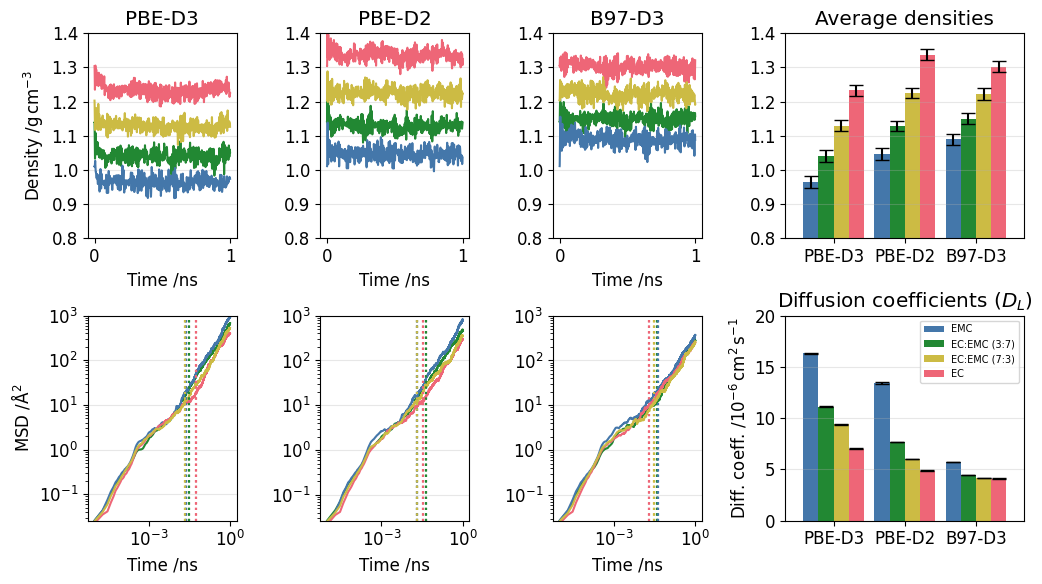

In [12]:
fig, axs = plt.subplots(2,len(tags)+1, figsize=(7*scale, 4*scale), gridspec_kw={'width_ratios': [1, 1, 1, 1.6]})

order = [
    'EMC',
    'EC:EMC (3:7)', 
    'EC:EMC (7:3)',
    'EC',
]
group_order = [
    'PBE-D3',
    'PBE-D2',
    'B97-D3',
]

# Pivot tables for plotting
plot_df = df.copy().drop('Seed ID', axis=1)
plot_df = plot_df.drop('Sample ID', axis=1)
avg_pivot_df = plot_df.pivot(
	index='Labels',
	columns='Composition',
	values='Density /g*cm-3',
).reindex(group_order)[order]

std_pivot_df = plot_df.pivot(
	index='Labels',
	columns='Composition',
	values='Density std. /g*cm-3',
).reindex(group_order)[order]

diff_pivot_df = plot_df.pivot(
	index='Labels',
	columns='Composition',
	values='Diff. coeff. /1e6 cm2*s-1',
).reindex(group_order)[order]

differr_pivot_df = plot_df.pivot(
	index='Labels',
	columns='Composition',
	values='Diff. fit slope error /1e6 cm2*s-1',
).reindex(group_order)[order]


# Plot trajectories
for i, tag in enumerate(thermo):
    data_set, labels, seed, dset_sample = tag.split('/')
    for j, (traj_name, traj_data) in enumerate(thermo[tag].items()):
        name = traj_map[traj_name]

        # Collect data
        ## If loading data from sources with a different structure from this, this must be controlled using
        ## the handle-variable. In such case, get_dynamic_data must also be modified to accomodate this.
        time, msd, dens = funcs.get_dynamic_data(traj_data, handle=labels)

        # Plot density
        axs[0,i].set_ylim([0.8, 1.4])
        if i == 0: axs[0,i].set_ylabel(f'Density /g$\\,$cm$^{{-3}}$')
        axs[0,i].plot(time/1e6,dens, label=name, color=funcs.get_colour(name))

        # Plot MSD
        axs[1,i].set_ylim([None, 1000])
        if i == 0: axs[1,i].set_ylabel(f'MSD /Å$^2$')
        axs[1,i].plot(time/1e6,msd, label=name, color=funcs.get_colour(name))
        axs[1,i].set_xscale('log')
        axs[1,i].set_yscale('log')

        # Plot vertical start times
        axs[1,0].axvline(plot_df['Start time /ns'].iloc[j], 0, 1, color=funcs.get_colour(name), alpha=1, linestyle='dotted')
        axs[1,1].axvline(plot_df['Start time /ns'].iloc[j+4], 0, 1, color=funcs.get_colour(name), alpha=1, linestyle='dotted')
        axs[1,2].axvline(plot_df['Start time /ns'].iloc[j+8], 0, 1, color=funcs.get_colour(name), alpha=1, linestyle='dotted')
      
        # Plot settings
        axs[0,i].set_title(label_map[labels])
        axs[0,i].set_xlabel(f'Time /ns')
        axs[1,i].set_xlabel(f'Time /ns')
        axs[0,i].grid(axis='y', alpha=0.3)
        axs[1,i].grid(axis='y', alpha=0.3)


# Plot averages
## Density
axs[0,-1].set_title('Average densities')
a0 = avg_pivot_df.plot.bar(
    ylim=[0.8,1.4],
    xlabel='',
	yerr=std_pivot_df,
    capsize=5,
    rot=0,
    width=0.85,
    color=[funcs.get_colour(o) for o in order],
    ax=axs[0,-1],
    legend=False,
)
axs[0,-1].grid(axis='y', alpha=0.3)

## Diff. coeff.
axs[1,-1].set_title('Diffusion coefficients ($D_L$)')
a1 = diff_pivot_df.plot.bar(
    ylim=[0,20],
    xlabel='',
    ylabel=f'Diff. coeff. /$10^{{-6}}\\,\\text{{cm}}^2\\,\\text{{s}}^{{-1}}$',
	yerr=differr_pivot_df,
    capsize=5,
    rot=0,
    width=0.85,
    color=[funcs.get_colour(o) for o in order],
    ax=axs[1,-1],
    legend=False,
)
axs[1,-1].grid(axis='y', alpha=0.3)
axs[1,-1].legend(loc='upper right', fontsize=fsize-5)

plt.tight_layout()

## Finite size correction of diffusion coefficients
For the diffusion data, we first need to compute the correction coefficients used by [Schrodinger SI, equ 5](https://pubs.acs.org/doi/suppl/10.1021/acs.jpcb.2c03746/suppl_file/jp2c03746_si_001.pdf) and [Bamboo, equ 61](https://arxiv.org/pdf/2404.07181), quoting [standard practice, equ 3](https://livecomsjournal.org/index.php/livecoms/article/view/v1i1e6324/937).
$$
D(\infty)=D(L)+\frac{2.837298\times k_BT}{6\pi \eta L}
$$
Box sizes are computed from number of molecules (table S1) and densities (table S2) from Schrodinger, temperatures are taken from table S1 and viscosity from table S3.

In [13]:
mass_thermo = funcs.get_all_thermo(f'{path}{tags[-1]}/dynamics/*', handle='.xyz') # Argument should be 'tag' to be consistent with zenodo

for comp, traj in mass_thermo.items():
    if '000conEC' in comp:
        print('Pure EMC:')
        M_EMC = traj[0].get_masses().sum() # u=g/mol
        m_EMC = M_EMC/ase.units.mol*1e-3 # g/mol*mol/1000=kg
        print(f'Total mass:\t{m_EMC} kg')
    elif '100conEC' in comp:
        print('Pure EC:')
        M_EC = traj[0].get_masses().sum() # u=g/mol
        m_EC = M_EC/ase.units.mol*1e-3 # g/mol*mol/1000=kg
        print(f'Total mass:\t{m_EC} kg')

./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


Pure EMC:
Total mass:	1.1582317925845882e-23 kg
Pure EC:
Total mass:	1.462303889780969e-23 kg


In [14]:
m_EC = 1.462303889780969e-23 # kg
eta_EC = 1.93e-3 # Pa s
m_EMC = 1.1582317925845882e-23 # kg
eta_EMC = 0.65e-3 # Pa s*
kB = ase.units.kB/ase.units.J
xi = 2.837298
print(f'EMC viscosity:\t{eta_EMC} Pa s (at 298 K)')
print(f'EC viscosity:\t{eta_EC} Pa s (at 313 K)')
print(f'kB:\t\t{kB} J\n')

corr_df = plot_df.copy()
corr_df = corr_df[(corr_df['Composition'] == 'EMC') | (corr_df['Composition'] == 'EC')]
for tag, data in thermo.items():
    print(tag)
    data_set, labels, seed, dset = tag.split('/')
    for comp, traj in data.items():
        temp = int(comp.split('_')[-1][:-1])
        time, msd, dens = funcs.get_dynamic_data(traj, handle=labels)
        dens = np.mean(dens)*1000 # kg/m3

        if '000conEC' in comp:
            print('EMC:')
            volume = m_EMC/dens # m3
            L = volume**(1/3) # m
            corr = xi*kB*temp/(6*np.pi*eta_EMC*L) # kT=[J]=[Pa m3] => Pa m3/(Pa s m)=m2/s
        elif '100conEC' in comp:
            print('EC:')
            volume = m_EC/dens # m3
            L = volume**(1/3) # m
            corr = xi*kB*temp/(6*np.pi*eta_EC*L) # kT=[J]=[Pa m3] => Pa m3/(Pa s m)=m2/s
        else:
            corr = 0
        
        corr *= 1e10 # 1e-6 cm2/s
        if corr > 0:
            print(f'Box length:\t{L*1e10:.3f} Å')
            print(f'Correction:\t{corr:.3f} 1e-6cm2/s\n')

        func_mask = corr_df['Labels'] == label_map[labels]
        comp_mask = corr_df['Composition'] == traj_map[comp]
        corr_df.loc[func_mask & comp_mask, 'Diff. coeff. /1e6 cm2*s-1'] += corr
corr_df

EMC viscosity:	0.00065 Pa s (at 298 K)
EC viscosity:	0.00193 Pa s (at 313 K)
kB:		1.38064852e-23 J

Periodic/PBED3/SEED1/DSET1
EMC:
Box length:	22.895 Å
Correction:	4.161 1e-6cm2/s

EC:
Box length:	22.805 Å
Correction:	1.478 1e-6cm2/s

Periodic/PBED2/SEED1/DSET1
EMC:
Box length:	22.281 Å
Correction:	4.276 1e-6cm2/s

EC:
Box length:	22.197 Å
Correction:	1.518 1e-6cm2/s

Periodic/B97D3/SEED1/DSET1
EMC:
Box length:	21.988 Å
Correction:	4.333 1e-6cm2/s

EC:
Box length:	22.391 Å
Correction:	1.505 1e-6cm2/s



,Data set,Labels,Composition,Temperature /K,Density /g*cm-3,Density std. /g*cm-3,Diff. coeff. /1e6 cm2*s-1,Diff. fit slope error /1e6 cm2*s-1,Diff. fit R2,Start time /ns,Start time R2
1,Periodic,PBE-D3,EMC,298,0.965048,0.016399,20.486966,0.059773,0.990634,0.02458,0.964739
2,Periodic,PBE-D3,EC,313,1.232997,0.016728,8.501776,0.031459,0.986518,0.05781,0.963111
5,Periodic,PBE-D2,EMC,298,1.047056,0.016843,17.703369,0.058968,0.986536,0.02136,0.972574
6,Periodic,PBE-D2,EC,313,1.337139,0.015780,6.407478,0.014162,0.994175,0.03427,0.954229
9,Periodic,B97-D3,EMC,298,1.089476,0.016971,10.040894,0.016959,0.993916,0.04106,0.976816
10,Periodic,B97-D3,EC,313,1.302671,0.015686,5.608728,0.013209,0.992714,0.02041,0.963113


___
# Supporting information

## A perspective on force errors

In [15]:
step_xyz = dict()
for tag in tags:
    step_xyz[tag] = funcs.get_all_thermo(f'{path}{tag}/dynamics/*', handle='.xyz')

./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz


./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz


./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz


./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


./data/Periodic/PBED2/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz


...

./data/Periodic/PBED2/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


In [16]:
step_lengths = []
for tag, thermo_dict in step_xyz.items():
    for config, traj in thermo_dict.items():
        x = [a.positions for a in traj]
        dxdt = np.concatenate([dx/10 for dx in np.diff(x)])
        step_lengths.append(np.mean(dxdt))

avg_step_length = np.mean(np.abs(step_lengths))
print(f'Avg. step length per atom per time step: {avg_step_length:.5f}')

Avg. step length per atom per time step: 0.02524


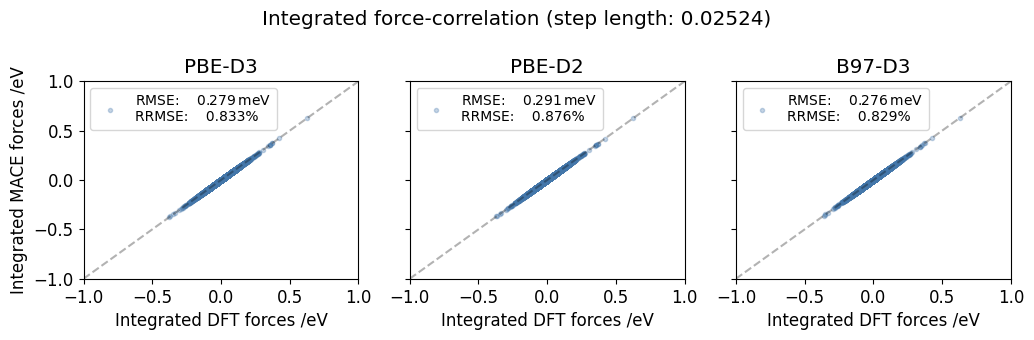

In [17]:
step_length = 0.02524

fig, axs = plt.subplots(1,len(tags), figsize=(7*scale, 2.3*scale), sharex=True, sharey=True)
for i, k in enumerate(step_xyz):
    tag = tags[i]
    atoms = xyz[k][3:]      # First three structures are just reference atoms with 0 energy and force.
    data_set, labels, seed, dset_sample = tag.split('/')
    
    # Obtain forces and errors
    ## reference
    ref_forces = [a.calc.results['forces']*step_length for a in atoms]
    
    ref_forces = np.concatenate(ref_forces).flatten()

    ## mace
    mace_forces = [a.arrays['MACE_forces']*step_length for a in atoms]
    mace_forces = np.concatenate(mace_forces).flatten()
    rmse, rrmse = funcs.RMSE(ref_forces, mace_forces)

    # Plot correlations
    axs[i].set_title(label_map[labels])
    axs[i].plot(ref_forces, mace_forces, '.', label=f'RMSE:    {rmse*1e3:.3f}$\\,$meV\nRRMSE:    {rrmse*100:.3f}%', alpha=0.3, rasterized=True)
    axs[i].legend(loc='upper left', numpoints=1, fontsize=fsize-2)

    # Plot settings
    axs[i].plot([0, 1], [0, 1], 'k--', transform=axs[i].transAxes, alpha=0.3)
    axs[i].set_xlabel('Integrated DFT forces /eV')
    axs[i].set_xlim([-1,1])
    axs[i].set_ylim([-1,1])
    if i == 0: axs[i].set_ylabel('Integrated MACE forces /eV')

fig.suptitle(f'Integrated force-correlation (step length: {step_length:.5f})')    
plt.tight_layout()

## Structural properties

In [18]:
try:
    with open('./part1_rdfs.pkl', 'rb') as f:
        rdfs = pickle.load(f)
    with open('./part1_rhos.pkl', 'rb') as f:
        number_densities = pickle.load(f)
except:
    rdfs, number_densities = funcs.get_mol_rdfs(path, tags)
    
    with open('./part1_rdfs.pkl', 'wb') as f:
        pickle.dump(rdfs, f)
    with open('./part1_rhos.pkl', 'wb') as f:
        pickle.dump(number_densities, f)

Periodic_PBED3 DSET1 SEED1
./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz


./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz


./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz


./data/Periodic/PBED3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


Periodic_PBED2 DSET1 SEED1
./data/Periodic/PBED2/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz


...

Periodic_B97D3 DSET1 SEED1
./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_000conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_066conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_033conEC_298K.xyz


./data/Periodic/B97D3/SEED1/DSET1/dynamics/npt_100conEC_313K.xyz


finished!


Average (std.) first shell coordinations:
B97-D3: R: 7.56 (0.42), CN: 10.42 (0.34)
PBE-D2: R: 7.45 (0.42), CN: 9.84 (0.36)
PBE-D3: R: 7.64 (0.40), CN: 9.74 (0.39)



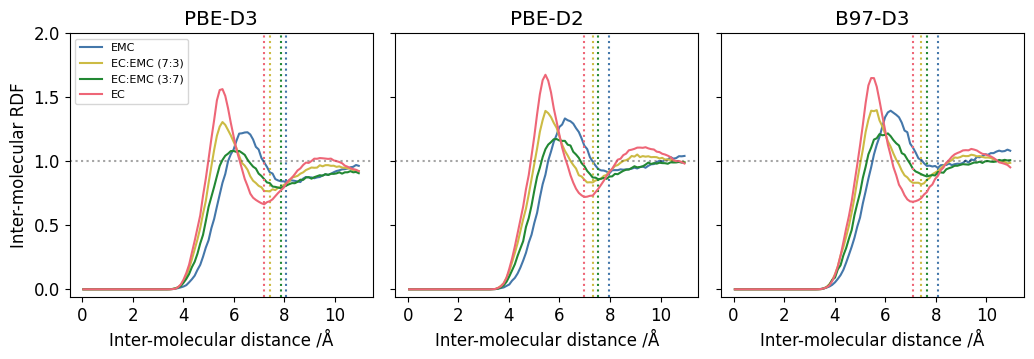

In [19]:
# These parameters controls the fitting of the vertical lines.
rstart = 6
id_width = 20

# Plot
radii = []
fig, axs = plt.subplots(1,3, figsize=(7*scale,2.5*scale), sharey=True)
axs[0].set_ylabel('Inter-molecular RDF')
for ax, (model,dsets) in zip(axs, rdfs.items()):
    ax.set_xlabel('Inter-molecular distance /Å')
    for dset,seeds in dsets.items():
        if dset == 'DSET1':
            for seed,comps in seeds.items():
                if seed == 'SEED1':
                    for comp, (g, r) in comps.items():
                        id0 = np.where(r>rstart)[0][0]                        
                        idhi = id0+id_width
                        rmin = min(r[id0:idhi])
                        idx = np.argmin(g[id0:idhi])

                        ax.axvline(r[id0+idx], 0, 1, color=funcs.get_colour(comp), alpha=1, linestyle='dotted')
                        ax.plot(r, g, label=comp, color=funcs.get_colour(comp))
                        ax.set_ylim(None,2)
                        ax.axhline(y=1.0, linestyle=':', color='black', alpha=0.1)
                        
                        rho = number_densities[model][dset][seed][comp]
                        r_prime = r[:id0+idx]
                        g_prime = g[1:id0+idx]                        
                        v_shell = 4/3*np.pi*(r_prime[1:]**3-r_prime[:-1]**3)
                        N = sum(g_prime*v_shell*rho)
                        
                        train_data, labels = model.split('_')
                        ax.set_title(label_map[labels])
                        
                        radii.append([label_map[labels], comp, r[id0+idx], N])
axs[0].legend(fontsize=fsize-4)
plt.tight_layout()


radii_df = pd.DataFrame(radii, columns=['Labels', 'Composition', 'Rmin', 'CN'])
print('Average (std.) first shell coordinations:')
for name, group in radii_df.groupby('Labels'):
    print(f'{name}: R: {group["Rmin"].mean():.2f} ({group["Rmin"].std():.2f}), CN: {group["CN"].mean():.2f} ({group["CN"].std():.2f})')
print()
radii_df.round(decimals=2)
plt.tight_layout()